In [ ]:
import pandas as pd
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
warnings.simplefilter(action='ignore', category=FutureWarning)


df = pd.read_csv("inversion_energetica_var_pob.csv")
print(df.head())
print(df.columns)

  municipio provincia                 ccaa  var_pob_2014_2023  \
0  Escatrón  Zaragoza               Aragón           5.480683   
1  Zaragoza  Zaragoza               Aragón           2.470506   
2    Madrid    Madrid  Comunidad de Madrid           5.269751   
3     Lorca    Murcia     Región de Murcia           7.288658   
4   Jumilla    Murcia     Región de Murcia           5.134244   

   num_infra_nuevas  
0                80  
1                57  
2                38  
3                35  
4                34  
Index(['municipio', 'provincia', 'ccaa', 'var_pob_2014_2023',
       'num_infra_nuevas'],
      dtype='object')


In [ ]:
# --- STYLE ---
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 1

Statistical Summary:
        var_pob_2014_2023  num_infra_nuevas
count        8131.000000       8131.000000
mean           -3.683861          0.656377
std            14.264770          2.049148
min           -67.746994          0.000000
25%           -12.632706          0.000000
50%            -4.185120          0.000000
75%             4.217023          1.000000
max           150.000000         80.000000


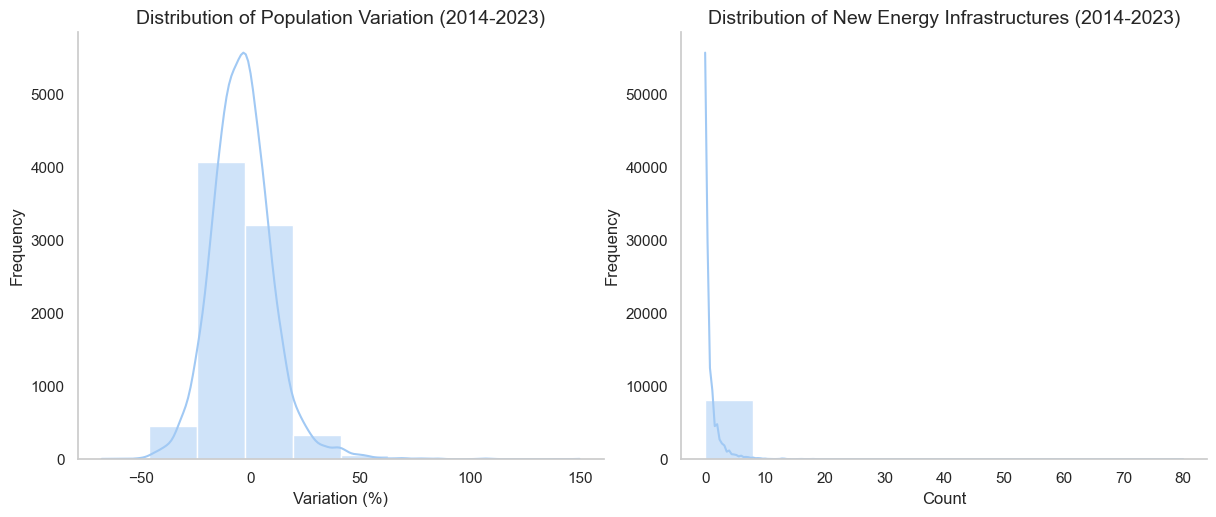

In [ ]:
# --- STATISTICAL SUMMARY ---
print("Statistical Summary:\n", df.describe())

# --- HISTOGRAMS ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['var_pob_2014_2023'], kde=True, bins=10)
plt.title('Distribution of Population Variation (2014-2023)', fontsize=14)
plt.xlabel('Variation (%)')
plt.ylabel('Frequency')
sns.despine()
plt.grid(False)

plt.subplot(1, 2, 2)
sns.histplot(df['num_infra_nuevas'], kde=True, bins=10)
plt.title('Distribution of New Energy Infrastructures (2014-2023)', fontsize=14)
plt.xlabel('Count')
plt.ylabel('Frequency')

plt.tight_layout()
sns.despine()
plt.grid(False)
plt.show()

Averages by province:
                         var_pob_2014_2023  num_infra_nuevas
provincia                                                  
A Coruña                        -4.646800          1.817204
Alacant-Alicante                 4.119852          0.000000
Albacete                        -8.434054          2.770115
Almería                          2.756461          0.951456
Araba-Álava                      1.053213          0.000000
Asturias                        -9.384576          2.089744
Badajoz                         -7.813437          0.000000
Barcelona                        6.656020          0.479100
Bizkaia                          1.294135          0.866071
Burgos                          -4.954399          0.339623
Cantabria                       -1.032795          0.774510
Castelló-Castellón               1.077620          0.000000
Ceuta                           -2.264515          1.000000
Ciudad Real                    -10.131339          1.607843
Cuenca           

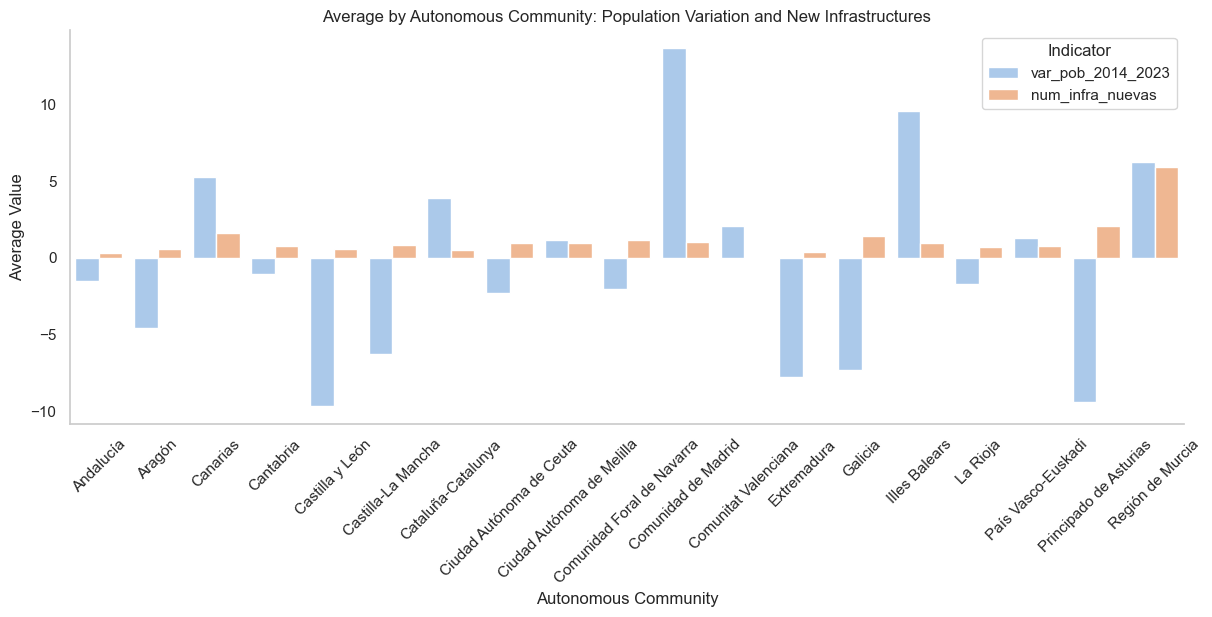

In [ ]:
# Aggregation by province
prov_summary = df.groupby('provincia')[['var_pob_2014_2023', 'num_infra_nuevas']].mean()
print("Averages by province:\n", prov_summary)

# Aggregation by autonomous community (CCAA)
ccaa_summary = df.groupby('ccaa')[['var_pob_2014_2023', 'num_infra_nuevas']].mean()
print("\nAverages by autonomous community:\n", ccaa_summary)

ccaa_summary = ccaa_summary.reset_index()

# Plot: comparison by CCAA
plt.figure(figsize=(12, 6))
ccaa_melted = ccaa_summary.melt(id_vars='ccaa', 
                                value_vars=['var_pob_2014_2023', 'num_infra_nuevas'],
                                var_name='Indicator', value_name='Average Value')

sns.barplot(data=ccaa_melted, x='ccaa', y='Average Value', hue='Indicator')
plt.title('Average by Autonomous Community: Population Variation and New Infrastructures')
plt.xlabel('Autonomous Community')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.legend(title='Indicator')
plt.grid(False)
sns.despine()
plt.tight_layout()
plt.show()

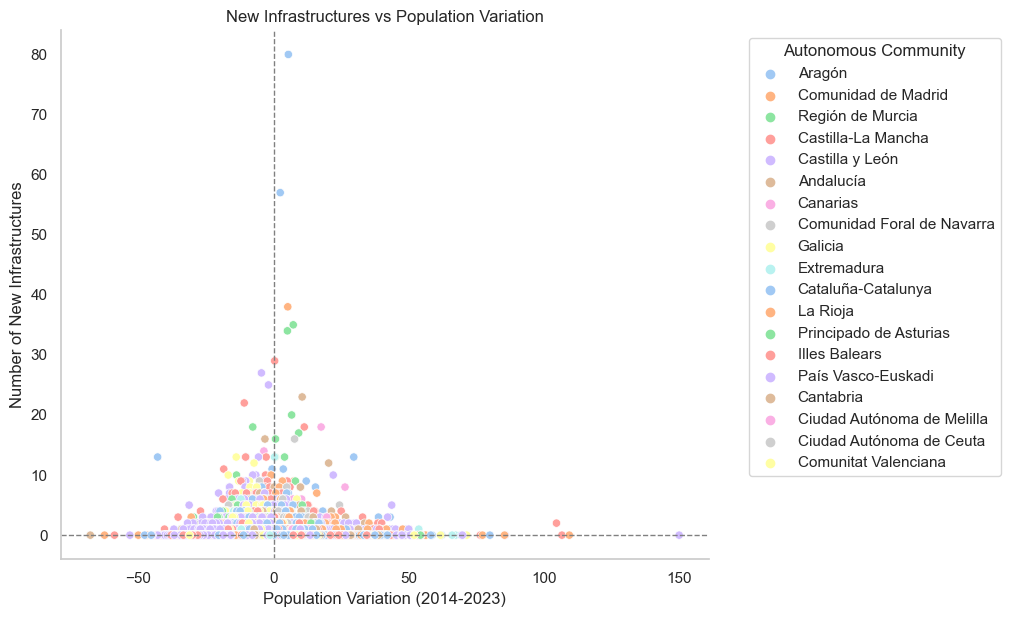

In [ ]:
# Extended pastel palette
palette = sns.color_palette("pastel", n_colors=df['ccaa'].nunique())

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='var_pob_2014_2023',
    y='num_infra_nuevas',
    hue='ccaa',
    palette=palette
)

plt.title('New Infrastructures vs Population Variation')
plt.xlabel('Population Variation (2014-2023)')
plt.ylabel('Number of New Infrastructures')


plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.axvline(0, color='grey', linestyle='--', linewidth=1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Autonomous Community')
plt.grid(False)
sns.despine()
plt.tight_layout()
plt.show()


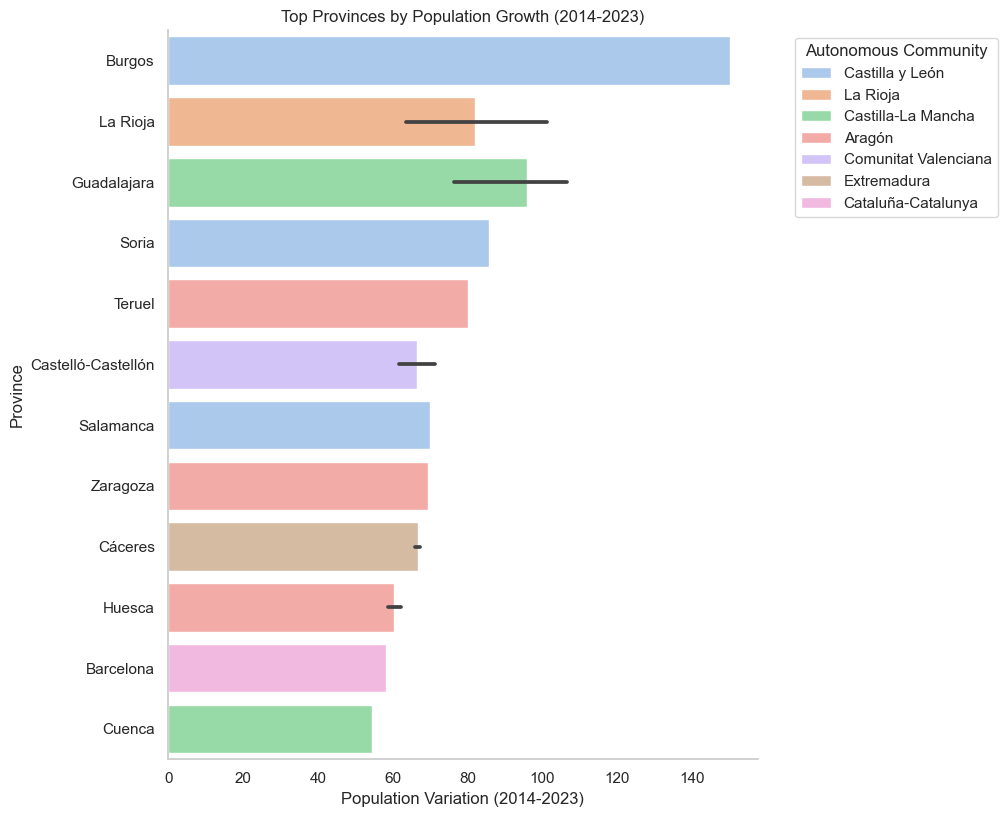

In [ ]:
# Top 20 municipalities by population variation
top_municipios = df.sort_values('var_pob_2014_2023', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_municipios, 
            x='var_pob_2014_2023', 
            y='provincia', 
            hue='ccaa', 
            dodge=False)

plt.title('Top Provinces by Population Growth (2014-2023)')
plt.xlabel('Population Variation (2014-2023)')
plt.ylabel('Province')
plt.grid(False)
sns.despine()
plt.legend(title='Autonomous Community', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


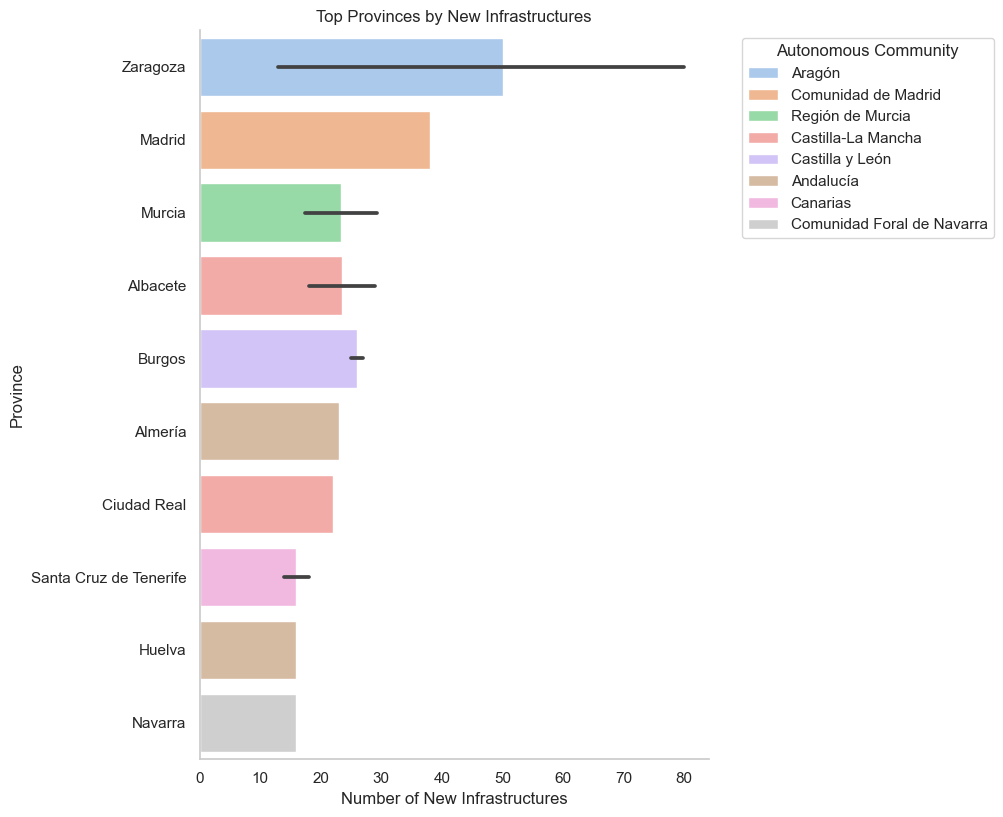

In [ ]:
# Top 20 provinces by number of new infrastructures
top_provinces = df.sort_values('num_infra_nuevas', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_provinces, 
            x='num_infra_nuevas', 
            y='provincia', 
            hue='ccaa', 
            dodge=False)

plt.title('Top Provinces by New Infrastructures')
plt.xlabel('Number of New Infrastructures')
plt.ylabel('Province')
plt.grid(False)
sns.despine()
plt.legend(title='Autonomous Community', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
